True coefficients: [ 0.   70.05 82.19 88.31  0.  ]
        x0     x1     x2     x3    x4  test_mse
mean  0.17  70.00  82.00  88.30  0.25    421.67
std   1.73   1.64   1.81   1.92  1.60     91.62
min  -3.10  66.47  77.81  84.47 -3.91    255.17
max   5.12  74.68  85.66  92.38  2.96    699.63


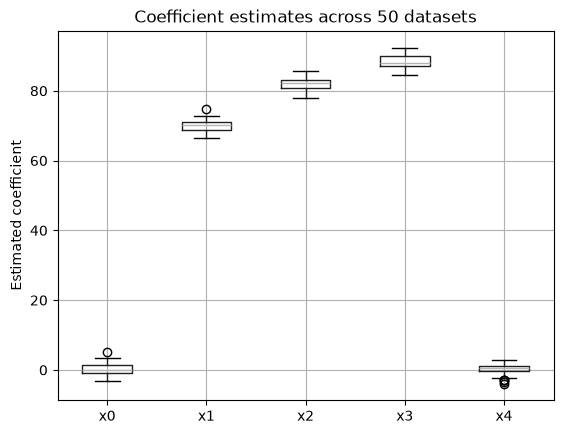

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import make_regression
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

n_samples = 200
n_features = 5
noise = 20

# Get the true coefficients once (3 features matter, 2 are pure noise)
_, _, true_coef = make_regression(n_samples=n_samples, n_features=n_features,
                                  n_informative=3, noise=noise,
                                  coef=True, random_state=0)

results = []

for seed in range(50):
    rng = np.random.default_rng(seed)
    X = rng.normal(size=(n_samples, n_features))
    y = X @ true_coef + rng.normal(scale=noise, size=n_samples)

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=seed)

    model = LinearRegression().fit(X_train, y_train)
    mse = mean_squared_error(y_test, model.predict(X_test))

    results.append(list(model.coef_) + [mse])

cols = [f"x{i}" for i in range(n_features)] + ["test_mse"]
df = pd.DataFrame(results, columns=cols)

print("True coefficients:", np.round(true_coef, 2))
print(df.describe().loc[["mean", "std", "min", "max"]].round(2))

# Boxplot of coefficient estimates across datasets
df.drop(columns="test_mse").boxplot()
plt.title("Coefficient estimates across 50 datasets")
plt.ylabel("Estimated coefficient")
plt.show()